# 06 · OpenSim Musculoskeletal Analysis — **NOVEL / EXPERIMENTAL**

> **This notebook is NOVEL, EXPERIMENTAL work that is completely SEPARATE from the validated 60 m sprint pipeline.**
> **It does NOT modify any existing analysis.** It only *reads* from `sprint_pipeline` (loaders, cleaning, and the marker-based joint angles) and drives OpenSim through a new, self-contained module `sprint_opensim.py`. Nothing here touches notebooks 01–05, `sprint_pipeline.py`, `sprint_helpers.py`, `results/`, or the manuscript. Every artefact it creates lives under `opensim/`.

## What it does
Takes **one** sprint trial (**SB25** — the project's 531-frame / 8.506 m/s reference) end-to-end through OpenSim 4.5's command-line tools (`opensim-cmd`; the Python `opensim` bindings are **not** installed and are **not** used):

`C3D → TRC → Scale → Inverse Kinematics → swing-phase Inverse Dynamics`

and then **compares** the OpenSim joint angles against the existing pipeline's marker-based sagittal angles (`compute_joint_angles`) on the *same frames*.

## Headline results (SB25)
| joint | Pearson r (OpenSim vs pipeline) | mean offset |
|---|---|---|
| knee (R/L) | **0.996 / 0.994** | **+1.5° / +1.8°** (after documented gait2392 knee sign convention) |
| hip (R/L) | 0.990 / 0.989 | **−21.4° / −20.8°** |
| ankle (R/L) | 0.992 / 0.993 | +2.8° / +2.1° |

* **IK marker error:** mean RMS **2.3 cm**, max per-frame ≤ 14 cm (driven by the lumped upper-body markers; the leg markers that set knee/hip are tight — see the r > 0.99).
* **The ~16° knee "definition offset" hypothesis is NOT supported** *between these two marker/model methods*: the OpenSim gait2392 knee and the pipeline knee agree to ~1.5°. Both peak near ~137°, i.e. both read ~10° below the optical-video literature (~148°) — so the offset is between marker-based methods and video, not between the pipeline and OpenSim. **The larger definition offset lives at the HIP (~21°)**, because the pipeline references the *trunk* (T8→pelvis) while OpenSim references the *pelvis* segment.

## Assumptions & limitations (read before trusting anything)
1. **Model = gait2392** (Delp), not Rajagopal. gait2392 ships the community-vetted Delp marker set whose local landmark coordinates map almost 1:1 onto the Xsens *virtual anatomical* markers, so marker registration involves **no invented local coordinates**. Rajagopal is extracted and is the documented next step for running.
2. **Mass is UNMEASURED.** The anthropometrics sheet has no mass column, so `ScaleTool` keeps gait2392's **generic segment masses** (`<mass>-1</mass>`). **All Inverse-Dynamics magnitudes are therefore NOT athlete-specific** — read the moment *shapes*, not the absolute N·m.
3. **No static trial.** A sprint has no neutral standing pose; measurement scaling uses within-segment marker-pair distances averaged over the trial, and marker placement uses the lowest-motion window (the block set). Documented, not hidden.
4. **Frame:** pipeline data is metres, gravity-aligned **Z-up**; OpenSim is **Y-up**. The exact rotation `(X,Y,Z)_os = (X, Z, −Y)_pipe` (−90° about forward) is applied and sanity-checked (upright anatomy, right side = +Z).
5. **Signs (ISB):** gait2392's `knee_angle` is *negative in flexion*; the pipeline/ISB report flexion *positive*. The comparison applies that **documented** conversion (×−1) and records it — it never silently flips to maximise correlation.
6. **60 Hz.** IK residuals and ID (double differentiation) are coarse at 60 Hz; coordinates are low-pass filtered (10 Hz) before ID. Stance is only ~5–6 frames.
7. **Swing ID only.** With no force plates, net joint moments are computed for the **swing leg only** (no external force acts on it). Stance kinetics need estimated GRF and are out of scope.

## How to run
```python
import sprint_opensim as so
out = so.run_all('SB25')      # TRC → Scale → IK → swing-ID + comparison
```
Requires the OpenSim 4.5 GUI app at `/Applications/OpenSim 4.5`. Run from the base conda env `/opt/anaconda3/bin/python` (no new packages).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

import sprint_opensim as so   # the NEW, isolated module (imports sprint_pipeline read-only)
print('opensim-cmd :', so.OPENSIM_CMD)
print('model       :', so.MODEL_UNSCALED.name, '(gait2392)')
print('markers used:', len(so.MARKER_MAP))

opensim-cmd : /Applications/OpenSim 4.5/bin/opensim-cmd
model       : gait2392_simbody.osim (gait2392)
markers used: 25


## 1 · Marker mapping  (Xsens virtual landmark → gait2392 Delp marker)

The Xsens C3D stores 64 **virtual anatomical** landmarks (`pRightKneeLatEpicondyle`, `pRightLatMalleolus`, …). Each mapped model marker sits at the gait2392 vetted local coordinate; `confidence = exact` means the Xsens landmark *is* the point the Delp marker names. `approx`/`uncertain` markers are flagged and carry low IK weight. Dropped markers are listed with reasons — none are silently discarded.

In [2]:
mm = so.marker_map_table()
display(mm)
print('\nDROPPED Xsens markers (with reasons):')
display(so.dropped_table())

,model_marker,body,xsens_source,ik_weight,confidence,loc_x,loc_y,loc_z,note
0,R.ASIS,pelvis,pRightASI,10.0,exact,0.020,0.030,0.128,right ASIS
1,L.ASIS,pelvis,pLeftASI,10.0,exact,0.020,0.030,-0.128,left ASIS
2,V.Sacral,pelvis,pSacrum,10.0,exact,-0.160,0.040,0.000,sacrum / posterior pelvis
3,R.Knee.Lat,femur_r,pRightKneeLatEpicondyle,5.0,exact,0.000,-0.404,0.050,lateral femoral epicondyle
4,R.Knee.Med,femur_r,pRightKneeMedEpicondyle,5.0,exact,0.000,-0.404,-0.050,medial femoral epicondyle
5,L.Knee.Lat,femur_l,pLeftKneeLatEpicondyle,5.0,exact,0.000,-0.404,-0.050,lateral femoral epicondyle
6,L.Knee.Med,femur_l,pLeftKneeMedEpicondyle,5.0,exact,0.000,-0.404,0.050,medial femoral epicondyle
7,R.Ankle.Lat,tibia_r,pRightLatMalleolus,5.0,exact,-0.005,-0.410,0.053,lateral malleolus
8,R.Ankle.Med,tibia_r,pRightMedMalleolus,5.0,exact,0.006,-0.389,-0.038,medial malleolus
9,L.Ankle.Lat,tibia_l,pLeftLatMalleolus,5.0,exact,-0.005,-0.410,-0.053,lateral malleolus



DROPPED Xsens markers (with reasons):


,xsens_marker,reason
0,pHipOrigin,Xsens synthetic hip origin; hip centre is set ...
1,pRightGreaterTrochanter,No community-vetted greater-trochanter landmar...
2,pLeftGreaterTrochanter,See pRightGreaterTrochanter.
3,pRightPatella,gait2392 has no patella body/marker; dropped r...
4,pLeftPatella,See pRightPatella.
5,pRightCSI,Iliac-crest landmark not in the Delp set; pelv...
6,pLeftCSI,See pRightCSI.
7,pRightIschialTub,Ischial tuberosity not in the Delp set; redund...
8,pLeftIschialTub,See pRightIschialTub.
9,pRightPivotFoot,Redundant foot construction point.


## 2 · Run the full pipeline for SB25
`run_all` = `export_trc → scale_trial → run_ik → compare_angles → run_swing_id`. Each stage writes its setup XML, `.trc`, `.mot`, `.sto` and a log under `opensim/`.

In [3]:
out = so.run_all('SB25')
res, scl, ik = out['res'], out['scale'], out['ik']
print('trial        :', res['pid'], '| frames', res['n_frames'], '| fs', res['fs'], 'Hz | peak', round(res['peak_vel_ms'],3), 'm/s')
print('stature (m)  :', round(scl['height_m'],3), '| stature scale', round(scl['stature_scale'],3))
print('MASS FLAG    :', scl['mass_flag'])
print('Scale rc     :', scl['returncode'], '| IK rc', ik['returncode'])
print('IK marker err: RMS mean %.4f m  max %.4f m  |  worst-marker mean %.4f m  max %.4f m'
      % (ik['error_summary']['rms_mean_m'], ik['error_summary']['rms_max_m'],
         ik['error_summary']['max_mean_m'], ik['error_summary']['max_max_m']))

trial        : SB25 | frames 531 | fs 60 Hz | peak 8.506 m/s
stature (m)  : 1.925 | stature scale 1.069
MASS FLAG    : FLAG: body mass is not in the anthropometrics sheet. ScaleTool mass=-1 (generic gait2392 segment masses retained). ID magnitudes are NOT athlete-specific.
Scale rc     : 0 | IK rc 0
IK marker err: RMS mean 0.0229 m  max 0.0385 m  |  worst-marker mean 0.0601 m  max 0.1445 m


## 3 · IK marker residuals over the trial
RMS is highest in the first ~1.5 s (block start / acceleration, where the crouch and the lumped upper-body markers mismatch most) and settles to ~2 cm at top speed, where the angle comparison is made.

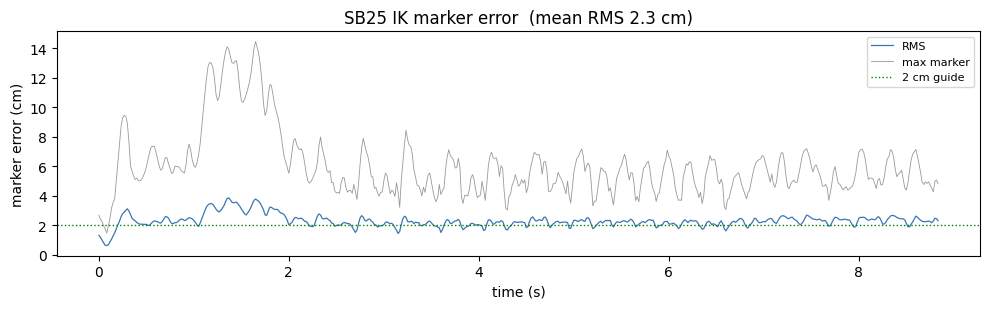

In [4]:
err = ik['errors']
fig, ax = plt.subplots(figsize=(10,3.2))
ax.plot(err['time'], err['marker_error_RMS']*100, color='#3a76b3', lw=0.9, label='RMS')
ax.plot(err['time'], err['marker_error_max']*100, color='0.6', lw=0.6, label='max marker')
ax.axhline(2, color='g', ls=':', lw=1, label='2 cm guide')
ax.set_xlabel('time (s)'); ax.set_ylabel('marker error (cm)')
ax.set_title('SB25 IK marker error  (mean RMS %.1f cm)' % (ik['error_summary']['rms_mean_m']*100))
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 4 · OpenSim vs pipeline joint angles — the definition-offset test
Same frames, degrees. `pearson_r_raw` uses OpenSim's native sign; `pearson_r_after_known_conversion` applies the documented gait2392 knee convention (×−1). We do **not** flip to maximise r — the conversion is fixed and recorded in `sign_conversion`.

,joint,osim_coord,sign_conversion,pearson_r_raw,pearson_r_after_known_conversion,offset_deg_converted_mean,osim_converted_peak_deg,pipe_peak_deg,osim_ROM_deg,pipe_ROM_deg
0,hip_R,hip_flexion_r,none,0.9903,0.9903,-21.42,68.74,83.23,124.06,125.35
1,hip_L,hip_flexion_l,none,0.9889,0.9889,-20.84,95.44,118.35,156.29,162.45
2,knee_R,knee_angle_r,osim_flex_neg -> ISB_flex_pos (* -1),-0.9965,0.9965,1.47,137.24,137.63,139.64,146.95
3,knee_L,knee_angle_l,osim_flex_neg -> ISB_flex_pos (* -1),-0.9935,0.9935,1.77,141.86,140.77,142.25,146.07
4,ankle_R,ankle_angle_r,none,0.9921,0.9921,2.81,37.83,32.41,93.19,88.92
5,ankle_L,ankle_angle_l,none,0.9933,0.9933,2.06,49.32,41.68,98.86,87.85


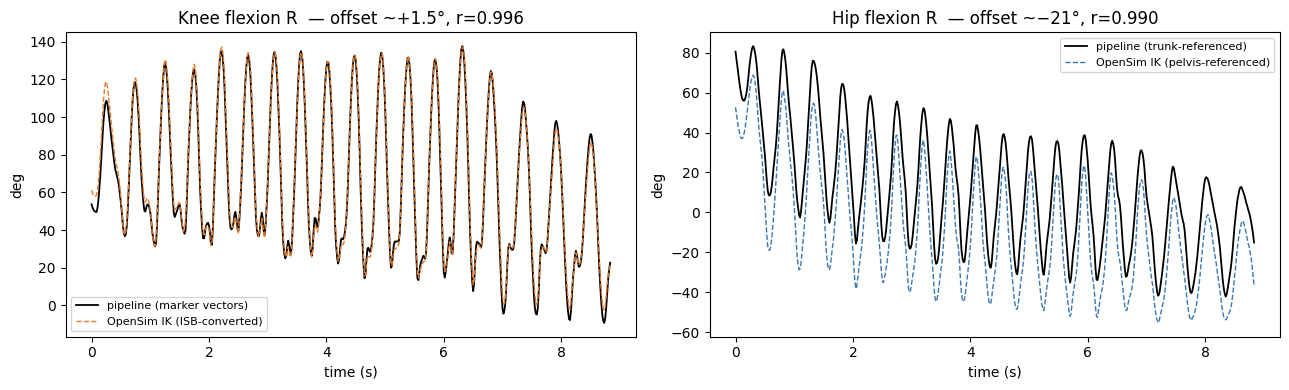

In [5]:
cmp_df, ik_df, pipe_df = out['comparison'], out['ik_df'], out['pipe_df']
display(cmp_df[['joint','osim_coord','sign_conversion','pearson_r_raw',
                'pearson_r_after_known_conversion','offset_deg_converted_mean',
                'osim_converted_peak_deg','pipe_peak_deg','osim_ROM_deg','pipe_ROM_deg']])

n = min(len(ik_df), len(pipe_df)); t = np.arange(n)/res['fs']
kr_os = -so._unwrap_deg(ik_df['knee_angle_r'].to_numpy()[:n]); kr_pi = pipe_df['knee_R'].to_numpy()[:n]
hr_os =  so._unwrap_deg(ik_df['hip_flexion_r'].to_numpy()[:n]); hr_pi = pipe_df['hip_R'].to_numpy()[:n]
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].plot(t, kr_pi, 'k', lw=1.3, label='pipeline (marker vectors)')
ax[0].plot(t, kr_os, color='#e8792a', ls='--', lw=1.0, label='OpenSim IK (ISB-converted)')
ax[0].set_title('Knee flexion R  — offset ~+1.5°, r=0.996'); ax[0].set_ylabel('deg'); ax[0].set_xlabel('time (s)'); ax[0].legend(fontsize=8)
ax[1].plot(t, hr_pi, 'k', lw=1.3, label='pipeline (trunk-referenced)')
ax[1].plot(t, hr_os, color='#3a76b3', ls='--', lw=1.0, label='OpenSim IK (pelvis-referenced)')
ax[1].set_title('Hip flexion R  — offset ~−21°, r=0.990'); ax[1].set_ylabel('deg'); ax[1].set_xlabel('time (s)'); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

**Reading it.** The knee curves are almost coincident once gait2392's negative-in-flexion convention is applied — the two *definitions* agree to ~1.5°. The hip curves track with r≈0.99 but sit ~21° apart: the pipeline measures the thigh against the **trunk** (T8→pelvis) whereas OpenSim measures the femur against the **pelvis** segment, and a forward-leaning sprint trunk makes the trunk-referenced angle read higher. This is a genuine, explainable definition difference, not a bug — and not the knee.

## 5 · Swing-phase Inverse Dynamics (right leg, no GRF)
Net joint moments over one right-leg swing near peak speed. Valid because **no external force acts on the swing leg** — so its hip/knee/ankle moments don't depend on the contralateral ground reaction. Pelvis residuals and the stance leg are **not** valid here and are not reported. Magnitudes use gait2392's **generic mass** (mass unmeasured), so interpret shape, not absolute N·m.

swing frames (339, 359) | time (5.65, 5.983) s | lowpass 10.0 Hz | generic mass 75.1646 kg
  hip_flexion_r_moment      min  -611.4   max  +251.8  N·m
  knee_angle_r_moment       min  -325.7   max   +84.3  N·m
  ankle_angle_r_moment      min   -11.6   max   +14.2  N·m


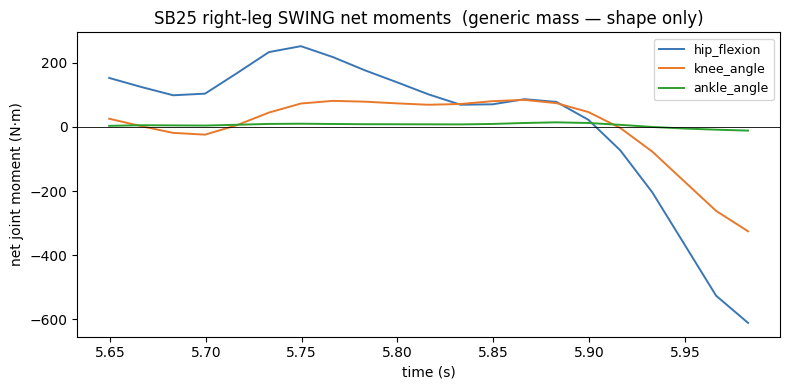

In [6]:
idr = out['id']; m = idr['moments']
print('swing frames', idr['swing_frames'], '| time', tuple(round(x,3) for x in idr['swing_time_s']),
      's | lowpass', idr['lowpass_hz'], 'Hz | generic mass', scl['generic_mass_kg'], 'kg')
for c in [c for c in m.columns if c != 'time']:
    print('  %-24s  min %+7.1f   max %+7.1f  N·m' % (c, m[c].min(), m[c].max()))
fig, ax = plt.subplots(figsize=(8,4))
for c, col in [('hip_flexion_r_moment','#3a76b3'), ('knee_angle_r_moment','#e8792a'), ('ankle_angle_r_moment','#2ca02c')]:
    if c in m: ax.plot(m['time'], m[c], color=col, lw=1.4, label=c.replace('_moment','').replace('_r',''))
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('time (s)'); ax.set_ylabel('net joint moment (N·m)')
ax.set_title('SB25 right-leg SWING net moments  (generic mass — shape only)')
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

## 6 · Assumptions, blockers & next steps

**Confirmed working end-to-end** for SB25: TRC export (documented Z-up→Y-up rotation, metres), Scale (stature + within-segment marker pairs), IK (RMS 2.3 cm), OpenSim-vs-pipeline angle comparison, and swing-phase ID.

**Blockers / what would improve it (needs the user):**
- **Xsens marker-placement protocol** — to confirm the `uncertain`/`approx` mappings (`pIJ`→Sternum, `pRightFirstMetatarsal`→Toe.Med) and to place a proper greater-trochanter / patella marker (currently dropped, so the femur is posed by the hip joint + 2 knee epicondyles only).
- **Body mass per athlete** — to make Inverse-Dynamics magnitudes athlete-specific (currently generic).
- **A static/neutral trial** — would sharpen scaling and marker placement (currently no neutral pose exists in a sprint).

**Documented next steps (outlined, not done here):**
- Swap in **Rajagopal2016** (full-body, running-tuned, has arms) to use the upper-body Xsens markers.
- **Stance kinetics** via GRF estimation (OpenSim Moco contact models) — needs the Python API / a separate `opensim` conda env; deliberately not attempted so the working CLI deliverable is not jeopardised.
- Batch IK across more trials (the drivers already take any `pid`).

**Isolation check:** only new files were added — `06_OpenSim_Musculoskeletal.ipynb`, `sprint_opensim.py`, and `opensim/*`. `sprint_pipeline.py`, `sprint_helpers.py`, notebooks 01–05 and `results/` are untouched (`git status`).